In [1]:
from google.colab import drive
import os

# 1. On connecte le Drive
drive.mount('/content/drive')

# 2. On se "déplace" dans votre dossier (comme la commande 'cd' sur terminal)
# Attention aux espaces : utilisez des guillemets ou un antislash
%cd "/content/drive/My Drive/pdos/Image-Processing-for-PDOs"

# 3. Vérification : on liste les fichiers pour être sûr qu'on est au bon endroit
!ls

Mounted at /content/drive
/content/drive/My Drive/pdos/Image-Processing-for-PDOs
 checkpoints		      detection_lora	    tokencut
 configs		      download_dataset.py   train_lora.ipynb
'Copie de train_lora.ipynb'   lightning_logs	    zeroshot_dinov2.ipynb
 data			      README.md		    zeroshot_dinov3.ipynb
 datasets		      requirements.txt


In [2]:
pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 66.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 73.2 MB/s eta 0:00:00


In [3]:
import os
import glob
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from detection_lora.train import train as run_train
from detection_lora.train import test as run_test
from detection_lora.data import OrganoidDetectionDataset
from detection_lora.detr_detection import LoRADetectionModel

In [4]:
# Device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)

Device: cuda


In [5]:
config = {
    'dataset_name': 'multiorg', # 'tellu', 'orgaquant', 'multiorg'
    'h5_path': None,
    'batch_size': 8,
    'max_epochs': 100,
    'output_dir': './checkpoints',
    # LoRA
    'lora_rank': 8,
    'lora_alpha': 16,
    'lora_dropout': 0.1,
    # Optim
    'lr': 1e-5,
    'lr_backbone': 1e-5,
    'weight_decay': 1e-4,
    # Patching
    'use_patching': True,
    'num_patches': None,
    'patch_size': 224,
    'overlap_size': 30,
}

for k, v in config.items():
    print(f"{k}: {v}")

dataset_name: multiorg
h5_path: None
batch_size: 8
max_epochs: 100
output_dir: ./checkpoints
lora_rank: 8
lora_alpha: 16
lora_dropout: 0.1
lr: 1e-05
lr_backbone: 1e-05
weight_decay: 0.0001
use_patching: True
num_patches: None
patch_size: 224
overlap_size: 30


In [6]:
def unnormalize_img(tensor_img):
    mean = np.array([0.485, 0.456, 0.406])[:, None, None]
    std = np.array([0.229, 0.224, 0.225])[:, None, None]
    img = tensor_img.cpu().numpy()
    img = (img * std + mean) * 255.0
    img = np.clip(img, 0, 255).astype(np.uint8)
    img = np.transpose(img, (1, 2, 0))
    return img

def cxcywh_to_xyxy(boxes):
    # boxes: (N,4) cx,cy,w,h (normalized)
    cx, cy, w, h = boxes.unbind(-1)
    x1 = cx - 0.5 * w
    y1 = cy - 0.5 * h
    x2 = cx + 0.5 * w
    y2 = cy + 0.5 * h
    return torch.stack([x1, y1, x2, y2], dim=-1)

In [7]:
ds = OrganoidDetectionDataset(
    dataset_name=config['dataset_name'],
    split='train',
    h5_path=config['h5_path'],
)
print('Dataset size:', len(ds))

[Dataset] multiorg/train:5851 images, task=detection, num_classes=1, original_size=(512, 512), resized_to=512x512
Dataset size: 5851


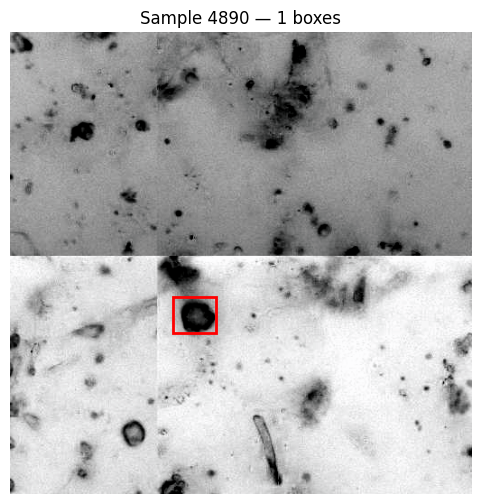

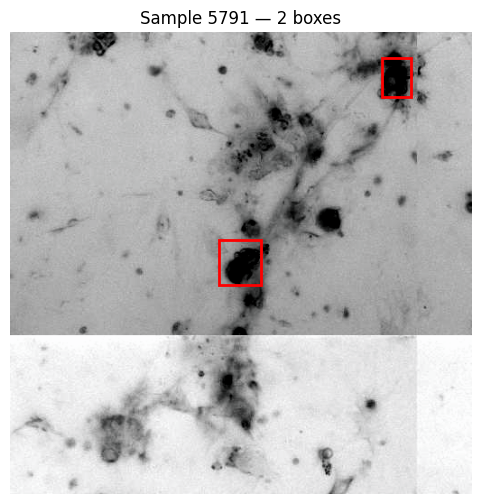

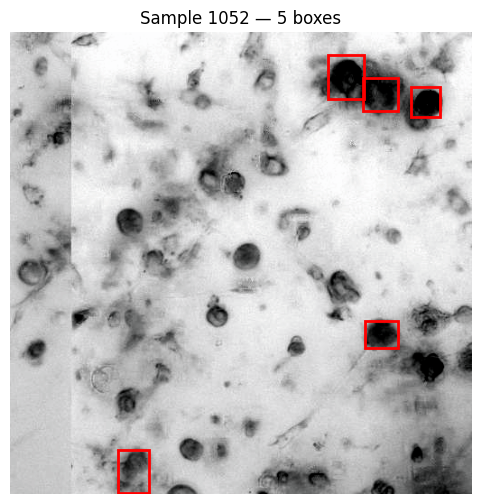

In [8]:
for i in np.random.choice(len(ds), size=3, replace=False):
    img_tensor, target = ds[i]
    boxes = target['boxes']
    labels = target['labels']

    img = unnormalize_img(img_tensor)
    h, w = img.shape[:2]
    boxes_xyxy = cxcywh_to_xyxy(boxes)
    boxes_xyxy = boxes_xyxy.cpu().numpy() * np.array([w, h, w, h])

    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    ax.imshow(img)
    for b in boxes_xyxy:
        x1, y1, x2, y2 = b
        rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, color='r', linewidth=2)
        ax.add_patch(rect)
    ax.set_title(f'Sample {i} — {len(boxes)} boxes')
    ax.axis('off')
    plt.show()

In [10]:
metrics = run_train(
    dataset_name=config['dataset_name'],
    h5_path=config['h5_path'],
    train_val_split=0.9,
    backbone_name='dinov2',
    backbone_size='base',
    num_classes=None,
    hidden_dim=256,
    num_queries=100,
    num_decoder_heads=8,
    num_decoder_layers=3,
    lora_rank=config['lora_rank'],
    lora_alpha=config['lora_alpha'],
    lora_dropout=config['lora_dropout'],
    lora_target_modules=["qkv", "proj", "fc1", "fc2"],
    cost_class=1.0,
    cost_bbox=5.0,
    cost_giou=2.0,
    eos_coef=0.1,
    lr=config['lr'],
    lr_backbone=config['lr_backbone'],
    weight_decay=config['weight_decay'],
    batch_size=config['batch_size'],
    max_epochs=config['max_epochs'],
    patience=10,
    num_workers=2,
    seed=42,
    output_dir=config['output_dir'],
    use_patching=config['use_patching'],
    num_patches=config['num_patches'],
    patch_size=config['patch_size'],
    overlap_size=config['overlap_size'],
)

print('Training finished. Returned metrics:')
print(metrics)

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


[Dataset] multiorg/train:5851 images, task=detection, num_classes=1, original_size=(512, 512), resized_to=512x512
[Info] Inferred num_classes=1 from dataset.
[Data] Train: 5265, Val: 586


INFO: Using 16bit Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


[PEFT] Applied LoRA with config:
  - rank: 8
  - alpha: 16
  - dropout: 0.1
  - target_modules: ['qkv', 'proj', 'fc1', 'fc2']
trainable params: 1,190,496 || all params: 87,770,976 || trainable%: 1.3564


/usr/local/lib/python3.12/dist-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /content/drive/MyDrive/pdos/Image-Processing-for-PDOs/checkpoints exists and is not empty.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


...

Output()

INFO: 
Detected KeyboardInterrupt, attempting graceful shutdown ...
INFO:lightning.pytorch.utilities.rank_zero:
Detected KeyboardInterrupt, attempting graceful shutdown ...


Exception in thread Thread-12 (_pin_memory_loop):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py", line 52, in _pin_memory_loop
    do_one_step()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py", line 28, in do_one_step
    r = in_queue.get(timeout=MP_STATUS_CHECK_INTERVAL)
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 122, in get
    return _ForkingPickler.loads(res)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/multiprocessing/reductions.py", line 540, in rebuild_storage_fd
    fd = df.detach()
         ^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/resource_

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/call.py", line 49, in _call_and_handle_interrupt
    return trainer_fn(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/trainer.py", line 630, in _fit_impl
    self._run(model, ckpt_path=ckpt_path, weights_only=weights_only)
  File "/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/trainer.py", line 1079, in _run
    results = self._run_stage()
              ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/trainer.py", line 1123, in _run_stage
    self.fit_loop.run()
  File "/usr/local/lib/python3.12/dist-packages/lightning/pytorch/loops/fit_loop.py", line 217, in run
    self.advance()
  File "/usr/local/lib/python3.12/dist-packages/lightning/pytorch/loops/fit_loop.py", line 465, in advance
    self.epoch_loop.run(self._data_fetcher)
  File

TypeError: object of type 'NoneType' has no len()

In [ ]:
metrics = run_test(
    ckpt_path="checkpoints/last_orgaquant.ckpt",
    dataset_name=config['dataset_name'],
    h5_path=config['h5_path'],
    train_val_split=0.9,
    backbone_name='dinov2',
    backbone_size='base',
    num_classes=1,
    hidden_dim=256,
    num_queries=100,
    num_decoder_heads=8,
    num_decoder_layers=3,
    lora_rank=config['lora_rank'],
    lora_alpha=config['lora_alpha'],
    lora_dropout=config['lora_dropout'],
    lora_target_modules=["qkv", "proj", "fc1", "fc2"],
    cost_class=1.0,
    cost_bbox=5.0,
    cost_giou=2.0,
    eos_coef=0.1,
    lr=config['lr'],
    lr_backbone=config['lr_backbone'],
    weight_decay=config['weight_decay'],
    batch_size=config['batch_size'],
    max_epochs=config['max_epochs'],
    patience=15,
    num_workers=2,
    seed=42,
    output_dir=config['output_dir'],
    use_patching=config['use_patching'],
    num_patches=config['num_patches'],
    patch_size=config['patch_size'],
    overlap_size=config['overlap_size'],
)

print('Test finished. Returned metrics:')
print(metrics)

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


[Dataset] orgaquant/test:112 images, task=localization, num_classes=1, original_size=None, resized_to=512x512
[Data] Test: 112
[Info] Inferred num_classes=1 from dataset.


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


[PEFT] Applied LoRA with config:
  - rank: 8
  - alpha: 16
  - dropout: 0.1
  - target_modules: ['qkv', 'proj', 'fc1', 'fc2']
trainable params: 1,190,496 || all params: 87,770,976 || trainable%: 1.3564


INFO: Using 16bit Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.

Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         val/loss          │    0.5446342825889587     │
│          val/mAP          │    0.6142169237136841     │
│        val/mAP_50         │     0.816288411617279     │
└───────────────────────────┴───────────────────────────┘

Training finished. Returned metrics:
[{'val/loss': 0.5446342825889587, 'val/mAP': 0.6142169237136841, 'val/mAP_50': 0.816288411617279}]


In [ ]:
metrics = run_test(
    ckpt_path="checkpoints/last_tellu.ckpt",
    dataset_name=config['dataset_name'],
    h5_path=config['h5_path'],
    train_val_split=0.9,
    backbone_name='dinov2',
    backbone_size='base',
    num_classes=1,
    hidden_dim=256,
    num_queries=100,
    num_decoder_heads=8,
    num_decoder_layers=3,
    lora_rank=config['lora_rank'],
    lora_alpha=config['lora_alpha'],
    lora_dropout=config['lora_dropout'],
    lora_target_modules=["qkv", "proj", "fc1", "fc2"],
    cost_class=1.0,
    cost_bbox=5.0,
    cost_giou=2.0,
    eos_coef=0.1,
    lr=config['lr'],
    lr_backbone=config['lr_backbone'],
    weight_decay=config['weight_decay'],
    batch_size=config['batch_size'],
    max_epochs=config['max_epochs'],
    patience=15,
    num_workers=2,
    seed=42,
    output_dir=config['output_dir'],
    use_patching=config['use_patching'],
    num_patches=config['num_patches'],
    patch_size=config['patch_size'],
    overlap_size=config['overlap_size'],
)

print('Test finished. Returned metrics:')
print(metrics)

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


[Dataset] tellu/test:84 images, task=detection, num_classes=1, original_size=(960, 1280), resized_to=1024x1024
[Data] Test: 84
[Info] Inferred num_classes=1 from dataset.
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vitb14/dinov2_vitb14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vitb14_pretrain.pth


100%|██████████| 330M/330M [00:05<00:00, 66.8MB/s]


[PEFT] Applied LoRA with config:
  - rank: 8
  - alpha: 16
  - dropout: 0.1
  - target_modules: ['qkv', 'proj', 'fc1', 'fc2']
trainable params: 1,190,496 || all params: 87,770,976 || trainable%: 1.3564


INFO: Using 16bit Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.

Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         val/loss          │     0.784426212310791     │
│          val/mAP          │    0.46990472078323364    │
│        val/mAP_50         │    0.8264725804328918     │
└───────────────────────────┴───────────────────────────┘

Training finished. Returned metrics:
[{'val/loss': 0.784426212310791, 'val/mAP': 0.46990472078323364, 'val/mAP_50': 0.8264725804328918}]


In [9]:
metrics = run_test(
    ckpt_path="checkpoints/last_tellu.ckpt",
    dataset_name=config['dataset_name'],
    h5_path=config['h5_path'],
    train_val_split=0.9,
    backbone_name='dinov2',
    backbone_size='base',
    num_classes=1,
    hidden_dim=256,
    num_queries=100,
    num_decoder_heads=8,
    num_decoder_layers=3,
    lora_rank=config['lora_rank'],
    lora_alpha=config['lora_alpha'],
    lora_dropout=config['lora_dropout'],
    lora_target_modules=["qkv", "proj", "fc1", "fc2"],
    cost_class=1.0,
    cost_bbox=5.0,
    cost_giou=2.0,
    eos_coef=0.1,
    lr=config['lr'],
    lr_backbone=config['lr_backbone'],
    weight_decay=config['weight_decay'],
    batch_size=config['batch_size'],
    max_epochs=config['max_epochs'],
    patience=15,
    num_workers=2,
    seed=42,
    output_dir=config['output_dir'],
    use_patching=config['use_patching'],
    num_patches=config['num_patches'],
    patch_size=config['patch_size'],
    overlap_size=config['overlap_size'],
)

print('Test finished. Returned metrics:')
print(metrics)

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


[Dataset] multiorg/test:793 images, task=detection, num_classes=1, original_size=(512, 512), resized_to=512x512
[Data] Test: 793
[Info] Inferred num_classes=1 from dataset.
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vitb14/dinov2_vitb14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vitb14_pretrain.pth


100%|██████████| 330M/330M [00:01<00:00, 286MB/s]


[PEFT] Applied LoRA with config:
  - rank: 8
  - alpha: 16
  - dropout: 0.1
  - target_modules: ['qkv', 'proj', 'fc1', 'fc2']
trainable params: 1,190,496 || all params: 87,770,976 || trainable%: 1.3564


INFO: Using 16bit Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.

Output()

AssertionError: Input image width 124 is not a multiple of patch width: 14

In [6]:
metrics = run_test(
    ckpt_path="checkpoints/last_orgaquant.ckpt",
    dataset_name=config['dataset_name'],
    h5_path=config['h5_path'],
    train_val_split=0.9,
    backbone_name='dinov2',
    backbone_size='base',
    num_classes=1,
    hidden_dim=256,
    num_queries=100,
    num_decoder_heads=8,
    num_decoder_layers=3,
    lora_rank=config['lora_rank'],
    lora_alpha=config['lora_alpha'],
    lora_dropout=config['lora_dropout'],
    lora_target_modules=["qkv", "proj", "fc1", "fc2"],
    cost_class=1.0,
    cost_bbox=5.0,
    cost_giou=2.0,
    eos_coef=0.1,
    lr=config['lr'],
    lr_backbone=config['lr_backbone'],
    weight_decay=config['weight_decay'],
    batch_size=config['batch_size'],
    max_epochs=config['max_epochs'],
    patience=15,
    num_workers=2,
    seed=42,
    output_dir=config['output_dir'],
    use_patching=config['use_patching'],
    num_patches=config['num_patches'],
    patch_size=config['patch_size'],
    overlap_size=config['overlap_size'],
)

print('Test finished. Returned metrics:')
print(metrics)

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


[Dataset] multiorg/test:793 images, task=detection, num_classes=1, original_size=(512, 512), resized_to=512x512
[Data] Test: 793
[Info] Inferred num_classes=1 from dataset.
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vitb14/dinov2_vitb14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vitb14_pretrain.pth


100%|██████████| 330M/330M [00:00<00:00, 384MB/s]


[PEFT] Applied LoRA with config:
  - rank: 8
  - alpha: 16
  - dropout: 0.1
  - target_modules: ['qkv', 'proj', 'fc1', 'fc2']
trainable params: 1,190,496 || all params: 87,770,976 || trainable%: 1.3564


INFO: Using 16bit Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.

Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         val/loss          │    1.2531051635742188     │
│          val/mAP          │    0.12174756824970245    │
│        val/mAP_50         │    0.25798556208610535    │
└───────────────────────────┴───────────────────────────┘

Test finished. Returned metrics:
[{'val/loss': 1.2531051635742188, 'val/mAP': 0.12174756824970245, 'val/mAP_50': 0.25798556208610535}]
